# 1. Librairies

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os

from skimage.transform import resize

import librosa

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

try :
    import torch_directml
    device = torch_directml.device(0) 
except:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

privateuseone:0


# 2. Téléchargement du dataset

In [3]:
audio_path = []
labels = []

for label in os.listdir('audio'):   
    for audio in os.listdir(f'audio/{label}'):
        audio_path.append(f'audio/{label}/{audio}')
        labels.append(label)

df = pd.DataFrame(zip(audio_path, labels), columns=['audio_path', 'class'])

print(df['class'].unique())
display(df.head())

<StringArray>
['bird', 'cat', 'dog']
Length: 3, dtype: str


,audio_path,class
0,audio/bird/00b01445_nohash_0.wav,bird
1,audio/bird/00f0204f_nohash_1.wav,bird
2,audio/bird/00f0204f_nohash_3.wav,bird
3,audio/bird/01648c51_nohash_0.wav,bird
4,audio/bird/01bcfc0c_nohash_1.wav,bird


# 3. Visualisation des données

In [4]:
def first_overview(df):
    print(f'Shape of dataset : {df.shape}\n')
    print(f'Number of duplicate : {df.duplicated().sum()}\n')
    if df.shape[1] < 20:
        print(f'Variable types : \n{df.dtypes}\n')
    else:
        print(f'Variable types : \n{df.dtypes.value_counts()}\n')
    display(df.head(2))
    display(df.describe().T)
    try:
        display(df.describe(include=('object', 'str')).T)
    except:
        pass
    return 

In [5]:
first_overview(df)

Shape of dataset : (610, 2)

Number of duplicate : 0

Variable types : 
audio_path    str
class         str
dtype: object



,audio_path,class
0,audio/bird/00b01445_nohash_0.wav,bird
1,audio/bird/00f0204f_nohash_1.wav,bird


,count,unique,top,freq
audio_path,610,610,audio/bird/00b01445_nohash_0.wav,1
class,610,3,dog,210


,count,unique,top,freq
audio_path,610,610,audio/bird/00b01445_nohash_0.wav,1
class,610,3,dog,210


In [6]:
print(f"\nClass distribution: \n{df['class'].value_counts()}")


Class distribution: 
class
dog     210
cat     207
bird    193
Name: count, dtype: int64


# 4. Encodage des catégories

In [22]:
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])

# 5. Segmentation des données

In [23]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=0)
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=0)

print(f'Train dataset shape : {train_df.shape}')
print(f'Validation dataset shape : {val_df.shape}')
print(f'Test dataset shape : {test_df.shape}')

Train dataset shape : (427, 2)
Validation dataset shape : (92, 2)
Test dataset shape : (91, 2)


# 6. Custom Dataset Class

In [24]:
class CustomAudioDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.labels = torch.Tensor(list(dataframe['class'])).type(torch.LongTensor).to(device)
        self.audios = [torch.Tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe['audio_path']]

    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = torch.Tensor(self.labels[idx]).to(device)
        audio = self.audios[idx].unsqueeze(0).to(device)
        return audio, label
    
    def get_spectogram(self, file_path):
        sr= 22050
        duration = 1

        img_height = 128
        img_width = 256

        signal, sr = librosa.load(file_path, sr=sr, duration=duration)
        spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        spec_db = librosa.power_to_db(spec , ref=np.max)

        spec_resized = librosa.util.fix_length(spec_db, size = (duration*sr) // 512+1)
        spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing=True)
        return spec_resized

# 7. Dataset object

In [25]:
train_dataset = CustomAudioDataset(dataframe=train_df)
val_dataset = CustomAudioDataset(dataframe=val_df)
test_dataset = CustomAudioDataset(dataframe=test_df)

# 8. Choix des hyper paramètres

In [26]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 20

# 9. Data loaders

In [27]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 10. Model class

In [28]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pooling = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear((64*16*32), 4096)
        self.linear2 = nn.Linear(4096, 1024)
        self.linear3 = nn.Linear(1024, 512)

        self.output = nn.Linear(512, len(df['class'].unique()))

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv1(x) 
        x = self.pooling(x)
        x = self.conv2(x) 
        x = self.pooling(x) 
        x = self.conv3(x) 
        x = self.pooling(x)
        x = self.relu(x)

        x = x.view(x.size(0), -1)

        x = self.flatten(x)
        x = self.linear1(x)
        x = self.dropout(x)

        x = self.linear2(x)
        x = self.dropout(x)

        x = self.linear3(x)
        x = self.dropout(x)

        x = self.output(x)
        return x

# 11. Création du model

In [29]:
model = Net().to(device)

In [30]:
try:
    summary(model, input_size = (1, 128, 256))
except:
    pass

# 12. Loss et Optimizer

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

# 13. Entrainement des données

In [32]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    len_train = len(train_dataset)
    len_val = len(val_dataset)

    total_loss_train_plot.append(round(total_loss_train/len_train, 4))
    total_loss_val_plot.append(round(total_loss_val/len_val, 4))  

    total_acc_train_plot.append(round((total_acc_train / len_train) * 100, 4))
    total_acc_val_plot.append(round((total_acc_val / len_val) * 100, 4))  
    
    print('='*25)
    print(f''' Epoch: {epoch+1}/{EPOCHS}, 
    Train Loss: {round(total_loss_train / len_train, 4)}, Train Accuracy: {round((total_acc_train / len_train) * 100, 4)}%
    Validation Loss: {round(total_loss_val / len_val, 4)}, Validation Accuracy: {round((total_acc_val / len_val) * 100, 4)}%
    ''')

 Epoch: 1/20, 
    Train Loss: 1.2885, Train Accuracy: 37.0023%
    Validation Loss: 0.5638, Validation Accuracy: 34.7826%
    
 Epoch: 2/20, 
    Train Loss: 0.1352, Train Accuracy: 44.2623%
    Validation Loss: 0.0608, Validation Accuracy: 55.4348%
    
 Epoch: 3/20, 
    Train Loss: 0.0427, Train Accuracy: 73.3021%
    Validation Loss: 0.0407, Validation Accuracy: 78.2609%
    
 Epoch: 4/20, 
    Train Loss: 0.0323, Train Accuracy: 78.9227%
    Validation Loss: 0.0307, Validation Accuracy: 80.4348%
    
 Epoch: 5/20, 
    Train Loss: 0.0199, Train Accuracy: 88.5246%
    Validation Loss: 0.0305, Validation Accuracy: 81.5217%
    
 Epoch: 6/20, 
    Train Loss: 0.0163, Train Accuracy: 91.5691%
    Validation Loss: 0.0256, Validation Accuracy: 83.6957%
    
 Epoch: 7/20, 
    Train Loss: 0.0139, Train Accuracy: 94.3794%
    Validation Loss: 0.02, Validation Accuracy: 86.9565%
    
 Epoch: 8/20, 
    Train Loss: 0.0119, Train Accuracy: 93.6768%
    Validation Loss: 0.0205, Validation Ac

# 14. Test du modèle

In [33]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for inputs, labels in test_loader:
        predictions = model(inputs)

        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()

        total_acc_test += (torch.argmax(predictions, axis=1) == labels).sum().item()

        len_test = len(test_dataset)   
        avg_loss_test = total_loss_test / len_test
        avg_acc_test = (total_acc_test / len_test) * 100

    print(f'''Test Loss: {round(avg_loss_test, 4)}, Test Accuracy: {round(avg_acc_test, 4)}%''')

Test Loss: 0.0284, Test Accuracy: 86.8132%


# 15. Visualisation de l'entrainement

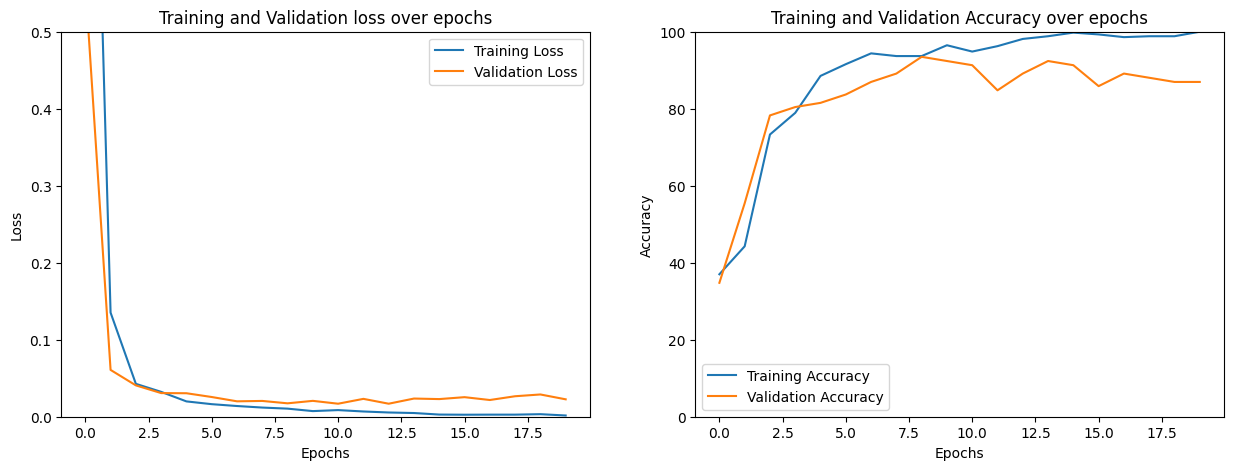

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].plot(total_loss_train_plot, label='Training Loss')
ax[0].plot(total_loss_val_plot, label='Validation Loss')
ax[0].set_title('Training and Validation loss over epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 0.5])
ax[0].legend()

ax[1].plot(total_acc_train_plot, label='Training Accuracy')
ax[1].plot(total_acc_val_plot, label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([0, 100])
ax[1].legend()

plt.show()